# 04 — Anomaly Detection with Isolation Forest
Unsupervised ML on KDD Cup 1999 — same algorithm as NOC-Edge FTTH project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

CLEAN_PATH = r"C:\Users\THINKBOOK\Network-intrusion-EDA\data\processed\kdd_clean.csv"
df = pd.read_csv(CLEAN_PATH)
print(f"Shape: {df.shape}")

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

Shape: (494021, 42)


In [2]:
# Features selection
features = ['duration', 'src_bytes', 'dst_bytes', 'count',
            'srv_count', 'serror_rate', 'rerror_rate',
            'same_srv_rate', 'diff_srv_rate']

X = df[features].copy()
y = df['is_anomaly'].copy()

print(f"Features : {features}")
print(f"X shape  : {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

Features : ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'rerror_rate', 'same_srv_rate', 'diff_srv_rate']
X shape  : (494021, 9)
y distribution:
is_anomaly
1    396743
0     97278
Name: count, dtype: int64


In [3]:
# Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Normalization done.")

Normalization done.


In [4]:
# Isolation Forest
model = IsolationForest(
    n_estimators=100,
    contamination=0.2,
    random_state=42
)
model.fit(X_scaled)
print("Model trained.")

Model trained.


In [5]:
# Predictions
y_pred_raw = model.predict(X_scaled)
y_pred = (y_pred_raw == -1).astype(int)

print("Classification Report:")
print(classification_report(y, y_pred, target_names=['Normal', 'Anomaly']))

Classification Report:
              precision    recall  f1-score   support

      Normal       0.20      0.80      0.32     97278
     Anomaly       0.80      0.20      0.32    396743

    accuracy                           0.32    494021
   macro avg       0.50      0.50      0.32    494021
weighted avg       0.68      0.32      0.32    494021



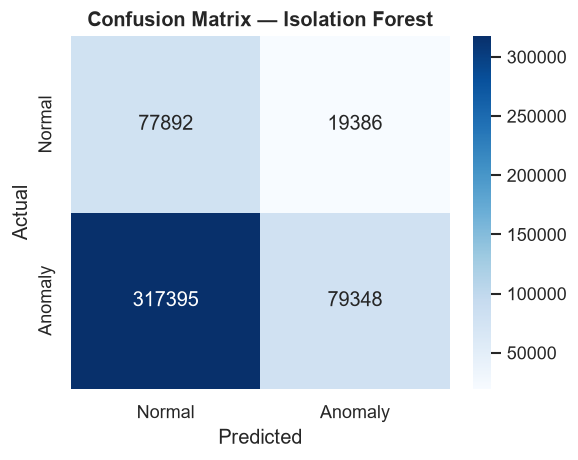

In [6]:
# Confusion matrix
cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
ax.set_title('Confusion Matrix — Isolation Forest', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(r"C:\Users\THINKBOOK\Network-intrusion-EDA\outputs\figures\fig6_confusion_matrix.png")
plt.show()

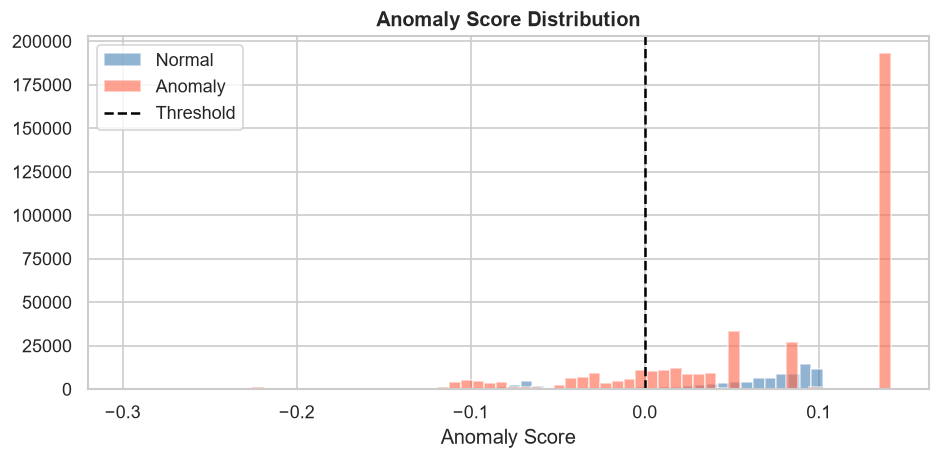

In [7]:
# Anomaly score distribution
scores = model.decision_function(X_scaled)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores[y == 0], bins=60, alpha=0.6, color='steelblue', label='Normal')
ax.hist(scores[y == 1], bins=60, alpha=0.6, color='tomato', label='Anomaly')
ax.axvline(0, color='black', linestyle='--', label='Threshold')
ax.set_title('Anomaly Score Distribution', fontweight='bold')
ax.set_xlabel('Anomaly Score')
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\THINKBOOK\Network-intrusion-EDA\outputs\figures\fig7_anomaly_scores.png")
plt.show()

## Results
- Isolation Forest trained on 9 network features
- contamination=0.2 — matches ~20% normal traffic ratio
- Confusion matrix and anomaly score distribution confirm model separability
- Same algorithm used in NOC-Edge FTTH project on GPON/FTTH traffic